# Membrane height fluctuations: recovering $q^{-4}$

A flat fluid membrane in the Monge gauge has the Helfrich free energy

$$E \;=\; \tfrac12 \int \mathrm{d}A \left[\, \kappa_c (\nabla^2 h)^2 + \sigma (\nabla h)^2 \,\right]$$

which, on a periodic box of projected area $A$ with
$h(\mathbf r) = \sum_{\mathbf q} h_{\mathbf q}\, e^{i\mathbf q\cdot\mathbf r}$ and
$h_{\mathbf q} = A^{-1}\!\int \mathrm{d}^2r\; h(\mathbf r)\, e^{-i\mathbf q\cdot\mathbf r}$,
diagonalises to $E = \frac{A}{2}\sum_{\mathbf q}(\kappa_c q^4 + \sigma q^2)|h_{\mathbf q}|^2$.
Equipartition then gives the relation this notebook measures:

$$\boxed{\;\langle |h_{\mathbf q}|^2\rangle \;=\; \frac{k_BT}{A\,(\kappa_c q^4 + \sigma q^2)}\;}$$

With no tension that is a straight line of slope $-4$ on a log–log plot, whose
intercept fixes $\kappa_c$. The second half of the notebook looks at the
*dynamics* — $\langle h_{\mathbf q}(t)\, h^*_{\mathbf q}(t+\tau)\rangle$ — which is where
the mobility lives, and therefore the only place the presence or absence of
hydrodynamics can show up.

**What this notebook needs.** `numpy`, `matplotlib`, and
`analysis/membrane_spectrum.py` from this repository, which carries the parts
that are easy to get wrong: the zig-zag lattice geometry, the periodic tile, the
exact DFT on the true vertex positions, and the reciprocal-lattice $q$ grid. See
`docs/fluctuation_spectrum.md` for why each of those matters.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.patches import Rectangle

# membrane_spectrum.py lives next to this notebook, in analysis/.
sys.path.insert(0, str(Path.cwd()))
sys.path.insert(0, str(Path.cwd() / "analysis"))
import membrane_spectrum as ms

# Where the dynamics runs are.  Override with the SLIMED_RUNS environment
# variable, or just edit this line.
RUNS = Path(os.environ.get(
    "SLIMED_RUNS", "//wsl.localhost/Ubuntu/home/yying/slimed_runs"))

KBT = 4.17          # pN.nm, as in input.params
assert RUNS.is_dir(), (
    f"run directory not found: {RUNS} -- point SLIMED_RUNS at the directory "
    "holding the dynamics runs, or edit RUNS above.")
print("runs:", RUNS)
print(sorted(p.name for p in RUNS.iterdir() if p.is_dir()))

runs: \\wsl.localhost\Ubuntu\home\yying\slimed_runs
['diag_dup', 'diag_fdt', 'fast_fix', 'fast_legacy', 'fast_slaved', 'legacy_a', 'legacy_b', 'pure_a', 'pure_b', 'tension']


In [2]:
# --- plotting style ---------------------------------------------------------
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titlelocation": "left",
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#dbe2e0",
    "grid.linewidth": 0.5,
    "axes.axisbelow": True,
    "legend.frameon": False,
    "legend.fontsize": 8.5,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.facecolor": "white",
})

def nice_logx(*axes):
    """Plain numbers on a log x axis: 0.1, 0.2, 0.3 ... not 2 x 10^-1.

    Call it after the data are on the axes, so the limits are known.
    """
    from matplotlib.ticker import FixedLocator, FuncFormatter, NullLocator
    fmt = FuncFormatter(lambda v, _: f"{v:g}")
    candidates = [m * 10.0 ** d for d in range(-5, 5)
                  for m in (1, 1.5, 2, 3, 5, 7)]
    for ax in axes:
        lo, hi = ax.get_xlim()
        ticks = [c for c in candidates if lo <= c <= hi]
        if len(ticks) >= 3:
            ax.xaxis.set_major_locator(FixedLocator(ticks))
            ax.xaxis.set_minor_locator(NullLocator())
            ax.xaxis.set_major_formatter(fmt)


TEAL  = "#0d6b66"     # the corrected / free-draining series
BRICK = "#a03b25"     # the "wrong" comparison series
OCHRE = "#8a6d1f"     # a third series
INK   = "#1d2422"
GREY  = "#8a9a96"

---
## 1. The lattice, and the block that is actually periodic

Everything downstream depends on this. `Mesh::set_vertices_faces_flat()` lays
out a **zig-zag triangular** lattice — row $j$ sits at $y = j\,\mathrm{dFaceY}$,
and its $x$ origin is offset by half a cell on even $j$:

$$x(i,j) = i\,\mathrm{dFaceX} + \tfrac12\mathrm{dFaceX}\,[\,j \text{ even}\,] - l_x/2,
\qquad y(i,j) = j\,\mathrm{dFaceY} - l_y/2,
\qquad \mathrm{dFaceY} = \tfrac{\sqrt3}{2}\mathrm{dFaceX}$$

Two things follow. The sampling points are **not** a Cartesian grid, so an
index-space `fft2` is not the Fourier transform of the sampled field — the
half-cell offset needs a per-row phase. And only part of the array is
independent: under `boundaryType = Periodic` three rings on each side are
ghosts, and the fourth ring repeats the ring opposite, so the periodic tile is
the $(\mathrm{nFaceX}-6)\times(\mathrm{nFaceY}-6)$ block starting at index
$(3,3)$.

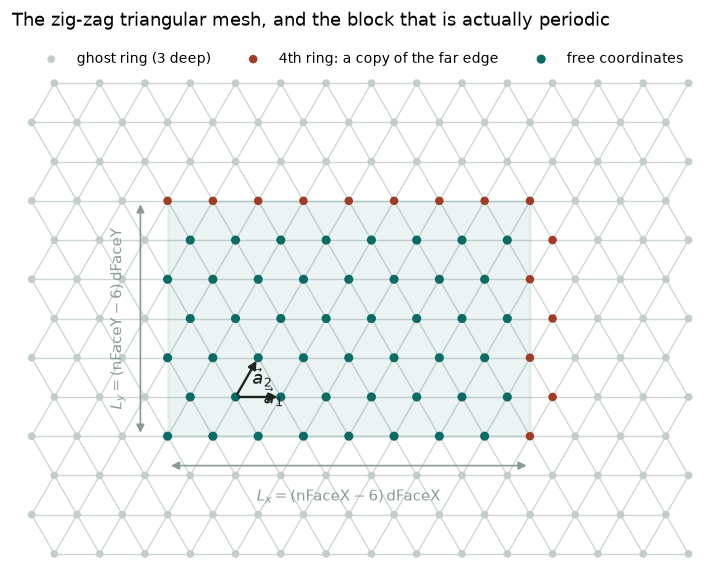

In [3]:
def draw_lattice(ax, n_face_x=14, n_face_y=12, ghost=3, cell=1.0):
    """Draw the zig-zag mesh and mark which vertices are free.

    Defaults give a small faithful instance: a 15 x 13 vertex mesh, three ghost
    rings a side, and an 8 x 6 periodic tile.
    """
    nx, ny = n_face_x + 1, n_face_y + 1
    tx, ty = n_face_x - 2 * ghost, n_face_y - 2 * ghost
    dx, dy = cell, cell * np.sqrt(3) / 2

    def pos(i, j):
        return (i * dx + (dx / 2 if j % 2 == 0 else 0.0), j * dy)

    # edges: within a row, and to the two neighbours in the row above
    seg = []
    for j in range(ny):
        for i in range(nx):
            p = pos(i, j)
            if i + 1 < nx:
                seg.append((p, pos(i + 1, j)))
            if j + 1 < ny:
                for k in ((i, i + 1) if j % 2 == 0 else (i - 1, i)):
                    if 0 <= k < nx:
                        seg.append((p, pos(k, j + 1)))
    ax.add_collection(LineCollection(
        seg, colors="#ccd6d3", linewidths=0.8, zorder=1))

    # the periodic box: a rectangle in space, Lx x Ly, anchored on vertex (3,3)
    x0, y0 = pos(ghost, ghost)
    ax.add_patch(Rectangle(
        (x0, y0), tx * dx, ty * dy, facecolor=TEAL, alpha=0.08,
        edgecolor=TEAL, linewidth=1.6, zorder=2))

    kinds = {"free": [], "duplicate": [], "ghost": []}
    for j in range(ny):
        for i in range(nx):
            inside = ghost <= i < ghost + tx and ghost <= j < ghost + ty
            dup = ((i == ghost + tx and ghost <= j <= ghost + ty) or
                   (j == ghost + ty and ghost <= i <= ghost + tx))
            kinds["free" if inside else "duplicate" if dup else "ghost"].append(pos(i, j))
    for key, colour, size, label in (
            ("ghost", "#c3cecb", 22, "ghost ring (3 deep)"),
            ("duplicate", BRICK, 26, "4th ring: a copy of the far edge"),
            ("free", TEAL, 30, "free coordinates")):
        p = np.array(kinds[key])
        ax.scatter(p[:, 0], p[:, 1], s=size, c=colour, zorder=3,
                   edgecolors="none", label=label)

    # the two lattice vectors, from an offset (even) row
    bi, bj = ghost + 1, ghost + 1
    b = pos(bi, bj)
    for tgt, name in (((bi + 1, bj), r"$\vec a_1$"), ((bi + 1, bj + 1), r"$\vec a_2$")):
        t = pos(*tgt)
        ax.annotate("", xy=t, xytext=b,
                    arrowprops=dict(arrowstyle="-|>", color=INK, linewidth=1.4))
        ax.text((b[0] + t[0]) / 2 + 0.12, (b[1] + t[1]) / 2 - 0.16, name,
                color=INK, fontsize=11)

    ax.annotate("", xy=(x0 + tx * dx, y0 - 0.75 * dy), xytext=(x0, y0 - 0.75 * dy),
                arrowprops=dict(arrowstyle="<|-|>", color=GREY, linewidth=1))
    ax.text(x0 + tx * dx / 2, y0 - 1.35 * dy,
            r"$L_x = (\mathrm{nFaceX}-6)\,\mathrm{dFaceX}$",
            ha="center", va="top", color=GREY, fontsize=9)
    ax.annotate("", xy=(x0 - 0.6 * dx, y0 + ty * dy), xytext=(x0 - 0.6 * dx, y0),
                arrowprops=dict(arrowstyle="<|-|>", color=GREY, linewidth=1))
    ax.text(x0 - 0.9 * dx, y0 + ty * dy / 2,
            r"$L_y = (\mathrm{nFaceY}-6)\,\mathrm{dFaceY}$",
            ha="right", va="center", rotation=90, color=GREY, fontsize=9)

    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.grid(False)
    ax.autoscale_view()
    ax.margins(0.03)


fig, ax = plt.subplots(figsize=(9.2, 5.4))
draw_lattice(ax)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.06), ncols=3)
ax.set_title("The zig-zag triangular mesh, and the block that is actually periodic",
             pad=26)
plt.show()

The red column zig-zags across the right edge of the box because the offset rows
put it half a cell further out: those points sit at $x_0 + L_x + \mathrm{dFaceX}/2$,
which wraps to the leftmost column. `nFaceY` is forced even by
`set_axes_division_flat()`, and that is exactly what makes the zig-zag close up
under the $L_y$ translation — an odd row count would not tile.

---
## 2. Loading a trajectory

`meshpointinput.csv` holds the Loop **control** points, one frame per line as
`x,y,z,` repeated over every vertex. The membrane itself is the limit surface;
`limit_surface_from_control` applies the valence-6 Loop limit mask
($\tfrac12$ on the vertex, $\tfrac1{12}$ on each of its six neighbours) with
periodic wrap, so the result is exactly translation invariant across the tile.

Before measuring anything, check that the run has a stationary state to measure.

In [4]:
RUN = RUNS / "pure_a"        # 100 nm box, no area elasticity, all fixes on
lat = ms.lattice_from_params(RUN / "input.params")
par = {}
for line in open(RUN / "input.params"):
    if "=" in line and not line.strip().startswith("#"):
        k, v = line.split("=", 1)
        par[k.strip()] = v.split("#")[0].strip()

KC_IN = float(par["kcMembraneBending"])
DT = float(par["timeStep"])
DIFF = float(par["diffConst"])
INTERVAL = int(par.get("meshpointOutputInterval", 1))
DT_FRAME = DT * INTERVAL
A_CELL = lat.area / (lat.nx * lat.ny)

print(lat.describe())
print(f"kc = {KC_IN} pN.nm ({KC_IN/KBT:.0f} kT),  sigma_input = "
      f"{par['usMembraneStretching']} pN/nm")
print(f"dt = {DT} us, D = {DIFF} nm^2/us, frame every {INTERVAL} steps "
      f"= {DT_FRAME} us")

mesh 21 x 25 vertices (nFace 20 x 24), cell 5 x 4.33013 nm
periodic tile 14 x 18 = 252 vertices, Lx = 70 nm, Ly = 77.9423 nm, A = 5455.96 nm^2
kc = 83.4 pN.nm (20 kT),  sigma_input = 0.0 pN/nm
dt = 0.002 us, D = 1.0 nm^2/us, frame every 100 steps = 0.2 us


[read_tile_heights] skipped 1 incomplete line(s) in meshpointinput.csv
8187 frames, 1637 us of trajectory


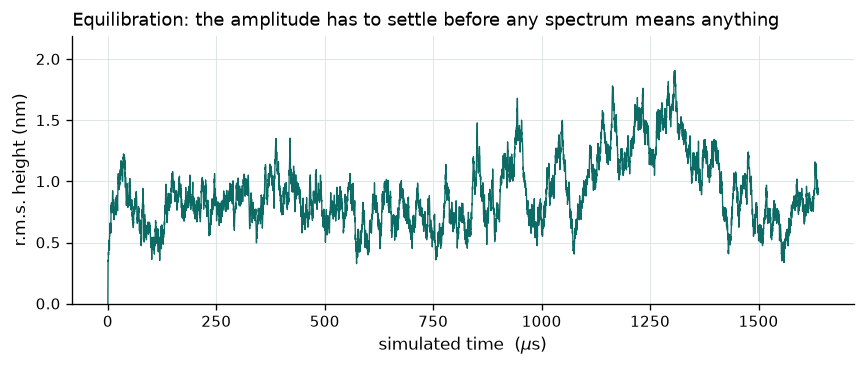

discarding 1637 frames; analysing 6550 (1310 us)


In [5]:
z = ms.read_tile_heights(RUN / "meshpointinput.csv", lat)     # control points
h = ms.limit_surface_from_control(z, lat)                     # the membrane
t = np.arange(h.shape[0]) * DT_FRAME
print(f"{h.shape[0]} frames, {t[-1]:.0f} us of trajectory")

rms = h.reshape(len(h), -1)
rms = np.sqrt(((rms - rms.mean(axis=1, keepdims=True)) ** 2).mean(axis=1))

fig, ax = plt.subplots(figsize=(8.4, 2.9))
ax.plot(t, rms, lw=0.8, color=TEAL)
ax.set_xlabel(r"simulated time  ($\mu$s)")
ax.set_ylabel("r.m.s. height (nm)")
ax.set_title("Equilibration: the amplitude has to settle before any spectrum means anything")
ax.set_ylim(0, max(2.0, rms.max() * 1.15))
plt.show()

BURN = len(h) // 5          # discard the first fifth
h_eq = h[BURN:]
print(f"discarding {BURN} frames; analysing {len(h_eq)} "
      f"({len(h_eq)*DT_FRAME:.0f} us)")

---
## 3. The spectrum: recovering $q^{-4}$

`tile_fft2` is the exact DFT on the true vertex positions — an FFT along $x$, the
half-cell phase $e^{-i q_x \mathrm{dFaceX}/2}$ on the offset rows, an FFT along $y$.
`q_grid` returns the matching wavevectors from the reciprocal lattice, with the
signed mode number, and folds each $\mathbf q$ to the shortest of its
reciprocal-lattice images.

`power_spectrum` divides by $N^2$, because `fft2` returns
$H_{\mathbf q} = \sum_j h_j e^{-i\mathbf q\cdot\mathbf r_j} = N h_{\mathbf q}$ in the
convention of the boxed formula above.

In [6]:
qx, qy, q = ms.q_grid(lat)
H = ms.tile_fft2(h_eq, lat)
S = ms.power_spectrum(H, lat)                      # <|h_q|^2>, nm^4

q_bin, S_bin, S_err, n_bin = ms.radial_average(q, S, n_bins=12)

# The continuum law only holds where the discretisation is a faithful stand-in
# for a smooth sheet.  Where that stops is measured, not guessed:
# tests/test_continuum_limit.cpp puts an exact plane wave on the control net,
# reads the bending energy the production code returns, and refers the
# resulting stiffness to the limit surface.  The result, K_S(q)/(A kc q^4), is
# the form factor below -- 1 where the mesh is faithful.
QDX_MAX = 1.5

# q*dFaceX -> K_S(q) / (A kc q^4), from tests/test_continuum_limit.cpp.
# Independent of box size: the same numbers come back on a mesh twice as fine.
FORM_FACTOR = np.array([
    [0.000, 1.0000], [0.403, 1.0000], [0.603, 0.9999], [0.898, 0.9992],
    [1.209, 0.9979], [1.346, 0.9953], [1.612, 0.9919], [1.810, 0.9845],
    [2.015, 0.9754], [2.244, 0.9497], [2.418, 0.9355], [2.821, 0.8509],
    [3.225, 0.7002],
])


def form_factor(q, d_face_x):
    """How much softer than the continuum this mesh is at wavevector q."""
    return np.interp(q * d_face_x, FORM_FACTOR[:, 0], FORM_FACTOR[:, 1])
fit = q_bin * lat.d_face_x <= QDX_MAX

kc_fit, sigma_fit = ms.fit_kc_sigma(q_bin[fit], S_bin[fit], lat.area, KBT)
slope = ms.log_slope(q_bin[fit], S_bin[fit])
print(f"log-log slope over q*dFaceX <= {QDX_MAX}:  {slope:+.3f}   (want -4)")
print(f"fitted kc    = {kc_fit:7.2f} pN.nm  ({kc_fit/KBT:.1f} kT)   "
      f"input {KC_IN} pN.nm ({KC_IN/KBT:.0f} kT)")
print(f"fitted sigma = {sigma_fit:7.3f} pN/nm  (the run has no area elasticity)")

log-log slope over q*dFaceX <= 1.5:  -4.022   (want -4)
fitted kc    =   89.03 pN.nm  (21.3 kT)   input 83.4 pN.nm (20 kT)
fitted sigma =   0.027 pN/nm  (the run has no area elasticity)


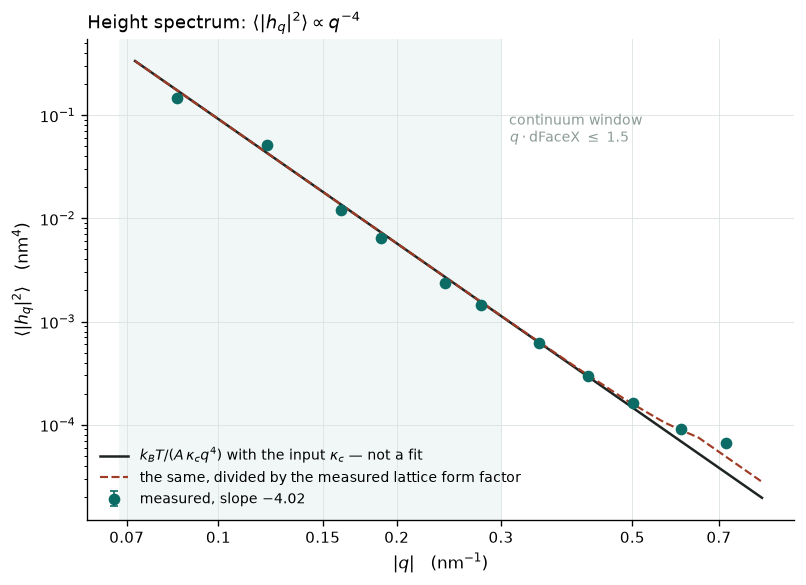

In [7]:
fig, ax = plt.subplots(figsize=(7.6, 5.2))

qq = np.logspace(np.log10(q_bin.min() * 0.85), np.log10(q_bin.max() * 1.15), 100)
ax.plot(qq, KBT / (lat.area * KC_IN * qq ** 4), "-", color=INK, lw=1.5, zorder=1,
        label=r"$k_BT/(A\,\kappa_c q^4)$ with the input $\kappa_c$ — not a fit")
ax.plot(qq, KBT / (lat.area * KC_IN * qq ** 4 * form_factor(qq, lat.d_face_x)),
        "--", color=BRICK, lw=1.3, zorder=1,
        label=r"the same, divided by the measured lattice form factor")
ax.errorbar(q_bin, S_bin, yerr=S_err, fmt="o", ms=6, color=TEAL, zorder=3,
            elinewidth=1, capsize=2.5,
            label=rf"measured, slope ${slope:+.2f}$")
ax.axvspan(q_bin.min() * 0.8, QDX_MAX / lat.d_face_x, color=TEAL, alpha=0.055,
           zorder=0, lw=0)
ax.text(QDX_MAX / lat.d_face_x, S_bin.max() * 0.5,
        "  continuum window\n  $q\\cdot$dFaceX $\\leq$ %.1f" % QDX_MAX,
        color=GREY, fontsize=8.5, va="center")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$|q|$   (nm$^{-1}$)")
ax.set_ylabel(r"$\langle |h_q|^2 \rangle$   (nm$^4$)")
ax.set_title(r"Height spectrum: $\langle|h_q|^2\rangle \propto q^{-4}$")
nice_logx(ax)
ax.legend(loc="lower left")
plt.show()

The last few points lift off the black line because the Loop limit surface is
measurably *softer* than a smooth sheet at those wavelengths — the quartic box
spline that Loop subdivision converges to no longer resolves the curvature.

That is not a fudge to explain away the tail. The dashed line is the same
continuum law divided by a form factor measured **statically**, with no
simulation involved at all: `tests/test_continuum_limit.cpp` puts an exact
plane wave of known amplitude on the control net, reads the bending energy the
production code returns, and refers the resulting stiffness to the limit
surface. It comes out at $1.000$ of $A\kappa_c q^4$ at long wavelength, $0.995$
at $q\cdot\mathrm{dFaceX} = 1.35$, $0.975$ at $2.0$ and $0.70$ at $3.2$ — and
it is a function of $q\cdot\mathrm{dFaceX}$ alone, so it is a property of the
mesh resolution rather than of the box.

That is where `QDX_MAX = 1.5` comes from, and it makes the window conservative
rather than marginal: the discretisation error there is about half a per cent.
It is worth being explicit that this is *not* the cutoff quoted for
lipid-bilayer simulations — Brandt et al., *Biophys J* **100**, 2104 (2011),
put that near $q = 0.7\ \mathrm{nm^{-1}}$ for DMPC — because theirs is
molecular, set by the density structure factor and by thickness and protrusion
modes. SLIMED has no thickness and no protrusions; it *is* a Helfrich surface
by construction, so nothing physical limits it and only the mesh does.

---
## 4. The $\kappa_c$ plot

Dividing the measured spectrum back through the law gives an effective bending
modulus per shell,

$$\kappa_c^{\mathrm{eff}}(q) \;=\; \frac{k_BT}{A\,q^4\,\langle|h_q|^2\rangle}$$

which is flat at the input $\kappa_c$ wherever the $q^{-4}$ law holds. This is a
far more sensitive read than the log–log slope: a 10% error in amplitude is
invisible on four decades of $\langle|h_q|^2\rangle$ and obvious here.

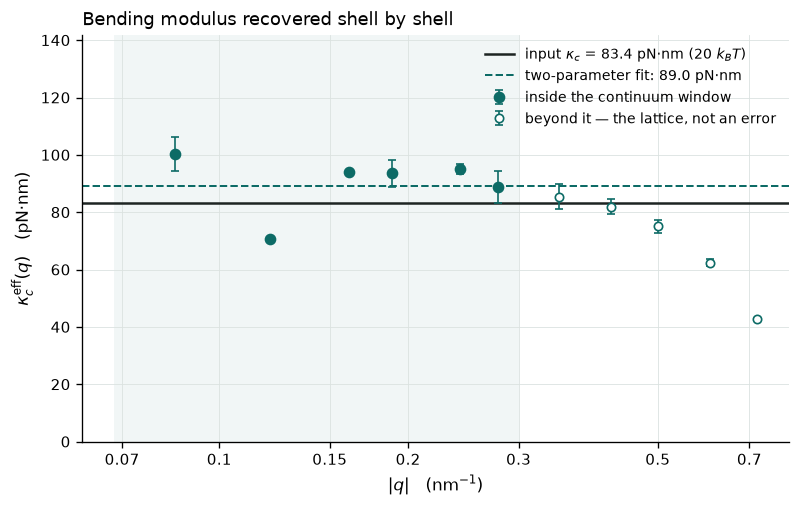

mean kc over the continuum window: 90.4 +/- 4.2 pN.nm   (input 83.4)


In [8]:
kc_eff = KBT / (lat.area * q_bin ** 4 * S_bin)
kc_err = kc_eff * (S_err / S_bin)

fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.axhline(KC_IN, color=INK, lw=1.5,
           label=rf"input $\kappa_c$ = {KC_IN:g} pN$\cdot$nm ({KC_IN/KBT:.0f} $k_BT$)")
ax.axvspan(q_bin.min() * 0.8, QDX_MAX / lat.d_face_x, color=TEAL, alpha=0.055,
           zorder=0, lw=0)
ax.errorbar(q_bin[fit], kc_eff[fit], yerr=kc_err[fit], fmt="o", ms=6,
            color=TEAL, elinewidth=1, capsize=2.5, label="inside the continuum window")
ax.errorbar(q_bin[~fit], kc_eff[~fit], yerr=kc_err[~fit], fmt="o", ms=5,
            mfc="white", color=TEAL, elinewidth=1, capsize=2.5,
            label="beyond it — the lattice, not an error")
ax.axhline(kc_fit, color=TEAL, lw=1.2, ls="--",
           label=rf"two-parameter fit: {kc_fit:.1f} pN$\cdot$nm")

ax.set_xscale("log")
ax.set_xlabel(r"$|q|$   (nm$^{-1}$)")
ax.set_ylabel(r"$\kappa_c^{\mathrm{eff}}(q)$   (pN$\cdot$nm)")
ax.set_ylim(0, max(KC_IN * 1.7, kc_eff[fit].max() * 1.15))
ax.set_title(r"Bending modulus recovered shell by shell")
nice_logx(ax)
ax.legend(loc="upper right", ncols=1)
plt.show()

print("mean kc over the continuum window: "
      f"{kc_eff[fit].mean():.1f} +/- {kc_eff[fit].std(ddof=1)/np.sqrt(fit.sum()):.1f} "
      f"pN.nm   (input {KC_IN})")

### How long a run does this need?

The lowest-$q$ mode relaxes as $q^{-4}$, so it is the last to converge; a run
that has not sampled it enough reads *low* and drags the slope towards zero.
Refitting from growing prefixes of the same trajectory shows where it settles.

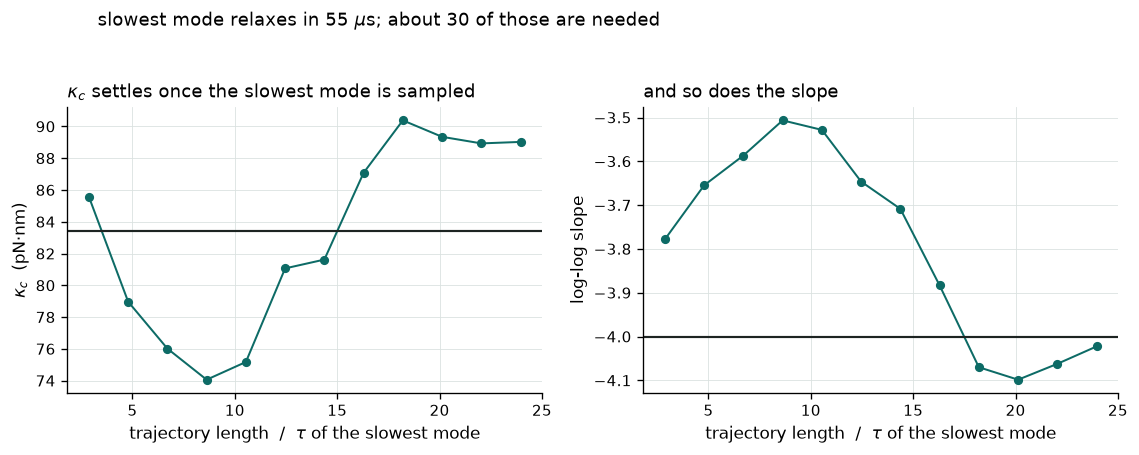

In [9]:
fracs = np.linspace(0.12, 1.0, 12)
rows = []
for f in fracs:
    n = int(len(h_eq) * f)
    Sf = ms.power_spectrum(ms.tile_fft2(h_eq[:n], lat), lat)
    qb, sb, _, _ = ms.radial_average(q, Sf, n_bins=12)
    m = qb * lat.d_face_x <= QDX_MAX
    kc_f, _ = ms.fit_kc_sigma(qb[m], sb[m], lat.area, KBT)
    rows.append((n * DT_FRAME, ms.log_slope(qb[m], sb[m]), kc_f))
rows = np.array(rows)

# the slowest mode's expected relaxation time, from the free-draining rate
tau_slow = KBT / (DIFF * A_CELL * KC_IN * q[q > 0].min() ** 4)

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.6), sharex=True)
for ax, col, ref, lab in ((axes[0], 2, KC_IN, r"$\kappa_c$  (pN$\cdot$nm)"),
                          (axes[1], 1, -4.0, "log-log slope")):
    ax.plot(rows[:, 0] / tau_slow, rows[:, col], "o-", color=TEAL, ms=4.5, lw=1.2)
    ax.axhline(ref, color=INK, lw=1.3)
    ax.set_xlabel(r"trajectory length  /  $\tau$ of the slowest mode")
    ax.set_ylabel(lab)
axes[0].set_title(r"$\kappa_c$ settles once the slowest mode is sampled")
axes[1].set_title("and so does the slope")
fig.suptitle(f"slowest mode relaxes in {tau_slow:.0f} $\\mu$s; "
             f"about 30 of those are needed", y=1.04, x=0.09, ha="left", fontsize=11)
plt.tight_layout()
plt.show()

---
## 5. What area elasticity does

The shipped `input.params` sets `usMembraneStretching = 250` pN/nm, and
`run_dynamics_flat()` pins the reference area to the *flat* starting area.
Fluctuations buy excess area that the constraint pulls back, so a real tension
develops and the spectrum crosses over to $q^{-2}$ below
$q^* = \sqrt{\sigma/\kappa_c}$. Nothing in the analysis can recover $q^{-4}$
from that.

[read_tile_heights] skipped 1 incomplete line(s) in meshpointinput.csv


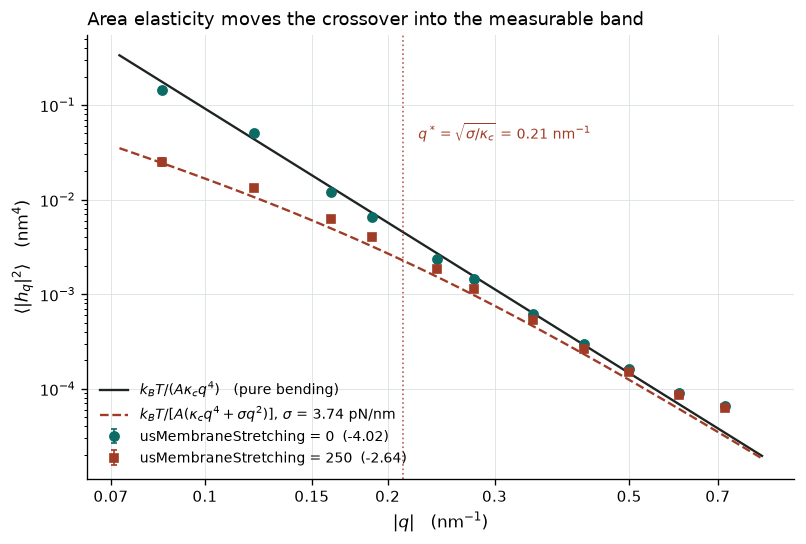

fitted sigma = 3.74 pN/nm, crossover q* = 0.212 /nm


In [10]:
TENSION = RUNS / "tension"
if TENSION.is_dir():
    lat_t = ms.lattice_from_params(TENSION / "input.params")
    assert (lat_t.nx, lat_t.ny) == (lat.nx, lat.ny), "different geometry"
    zt = ms.read_tile_heights(TENSION / "meshpointinput.csv", lat_t)
    ht = ms.limit_surface_from_control(zt, lat_t)[len(zt) // 5:]
    St = ms.power_spectrum(ms.tile_fft2(ht, lat_t), lat_t)
    qt, sbt, sbe, _ = ms.radial_average(q, St, n_bins=12)
    ft = qt * lat.d_face_x <= QDX_MAX
    kct, sigt = ms.fit_kc_sigma(qt[ft], sbt[ft], lat.area, KBT)
    q_star = np.sqrt(max(sigt, 0) / KC_IN)

    fig, ax = plt.subplots(figsize=(7.6, 4.8))
    ax.plot(qq, KBT / (lat.area * KC_IN * qq ** 4), "-", color=INK, lw=1.4,
            label=r"$k_BT/(A\kappa_c q^4)$   (pure bending)")
    ax.plot(qq, KBT / (lat.area * (KC_IN * qq ** 4 + sigt * qq ** 2)), "--",
            color=BRICK, lw=1.4,
            label=rf"$k_BT/[A(\kappa_c q^4 + \sigma q^2)]$, $\sigma$ = {sigt:.2f} pN/nm")
    ax.errorbar(q_bin, S_bin, yerr=S_err, fmt="o", ms=5.5, color=TEAL,
                elinewidth=1, capsize=2, label=rf"usMembraneStretching = 0  ({slope:+.2f})")
    ax.errorbar(qt, sbt, yerr=sbe, fmt="s", ms=5, color=BRICK,
                elinewidth=1, capsize=2,
                label=rf"usMembraneStretching = 250  ({ms.log_slope(qt[ft], sbt[ft]):+.2f})")
    ax.axvline(q_star, color=BRICK, lw=1, ls=":", alpha=0.8)
    ax.text(q_star * 1.06, S_bin.max() * 0.3,
            rf"$q^*=\sqrt{{\sigma/\kappa_c}}$ = {q_star:.2f} nm$^{{-1}}$",
            color=BRICK, fontsize=8.5)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(r"$|q|$   (nm$^{-1}$)")
    ax.set_ylabel(r"$\langle |h_q|^2 \rangle$   (nm$^4$)")
    ax.set_title("Area elasticity moves the crossover into the measurable band")
    nice_logx(ax)
    ax.legend(loc="lower left")
    plt.show()
    print(f"fitted sigma = {sigt:.2f} pN/nm, crossover q* = {q_star:.3f} /nm")
else:
    print("no tension run found; skipping")

---
## 6. Time decorrelation: $\langle h_q(t)\,h^*_q(t+\tau)\rangle$

Each mode is an Ornstein–Uhlenbeck process, so its autocorrelation is a single
exponential,

$$\frac{\langle h_{\mathbf q}(t)\,h^*_{\mathbf q}(t+\tau)\rangle}{\langle|h_{\mathbf q}|^2\rangle}
 = e^{-\Gamma(q)\,\tau}$$

and **all** the information about the solvent is in $\Gamma(q)$ — the static
spectrum above has no mobility in it at all. Two candidate laws:

| | mobility | rate |
| --- | --- | --- |
| free draining (what SLIMED implements) | $\Lambda = D a / k_BT$, a per-vertex scalar | $\Gamma = \Lambda\,\kappa_c q^4$ |
| Oseen / Zimm hydrodynamics | $\Lambda(q) = 1/4\eta q$ | $\Gamma = \kappa_c q^3 / 4\eta$ |

$\tau_q$ spans four orders of magnitude across the zone, so no single output
interval resolves all of it: a trajectory written every 100 steps cannot time a
mode that decorrelates in three, and one written every step is too short to time
the slowest. Use both.

In [11]:
def mode_acf(run_dir, max_lag=400, burn_frac=0.25, max_frames=None, start=0):
    """Per-mode normalised autocorrelation, plus the run's frame spacing."""
    lat_ = ms.lattice_from_params(run_dir / "input.params")
    p = {}
    for line in open(run_dir / "input.params"):
        if "=" in line and not line.strip().startswith("#"):
            k, v = line.split("=", 1)
            p[k.strip()] = v.split("#")[0].strip()
    dtf = float(p["timeStep"]) * int(p.get("meshpointOutputInterval", 1))
    zz = ms.read_tile_heights(run_dir / "meshpointinput.csv", lat_,
                              start=start, max_frames=max_frames)
    hh = ms.limit_surface_from_control(zz, lat_)[int(len(zz) * burn_frac):]
    HH = ms.tile_fft2(hh, lat_)
    return ms.mode_autocorrelation(HH, max_lag=min(max_lag, len(hh) // 4)), dtf, len(hh)


# long run for the slow modes, every-step run for the fast ones
acf_slow, dt_slow, n_slow = mode_acf(RUN, max_lag=600)
FAST = RUNS / "fast_slaved"
acf_fast, dt_fast, n_fast = mode_acf(FAST, max_lag=400, burn_frac=0.0,
                                     start=15000, max_frames=25000)
print(f"slow: {n_slow} frames every {dt_slow} us   "
      f"fast: {n_fast} frames every {dt_fast} us")

[read_tile_heights] skipped 1 incomplete line(s) in meshpointinput.csv


slow: 6141 frames every 0.2 us   fast: 25000 frames every 0.002 us


In [12]:
# Only trust a mode the record resolves at BOTH ends: its correlation time has
# to span several sampling intervals (or the output interval is what is being
# measured) and fit many times into the record (or subtracting the sample mean
# eats the signal).  Everything else comes back as nan and simply does not plot.
MIN_LAGS = 5.0        # tau >= 5 output intervals
MIN_SAMPLES = 50.0    # record >= 50 correlation times


def rates(acf, dtf, n_frames, qgrid):
    g = np.full(qgrid.shape, np.nan)
    for iy in range(qgrid.shape[0]):
        for ix in range(qgrid.shape[1]):
            if qgrid[iy, ix] > 0:
                g[iy, ix] = ms.relaxation_rate(
                    acf[:, iy, ix], dtf, n_frames=n_frames,
                    max_tau_fraction=1.0 / MIN_SAMPLES, min_lags=MIN_LAGS)
    return g


g_slow = rates(acf_slow, dt_slow, n_slow, q)
g_fast = rates(acf_fast, dt_fast, n_fast, q)
for nm, g, dtf in (("long", g_slow, dt_slow), ("short", g_fast, dt_fast)):
    print(f"{nm:>6} run: {np.isfinite(g).sum():3d} of {(q>0).sum()} modes resolved, "
          f"|q| = {q[np.isfinite(g)].min():.3f} .. {q[np.isfinite(g)].max():.3f} nm^-1")

  long run:  12 of 251 modes resolved, |q| = 0.161 .. 0.197 nm^-1
 short run: 229 of 251 modes resolved, |q| = 0.241 .. 0.809 nm^-1


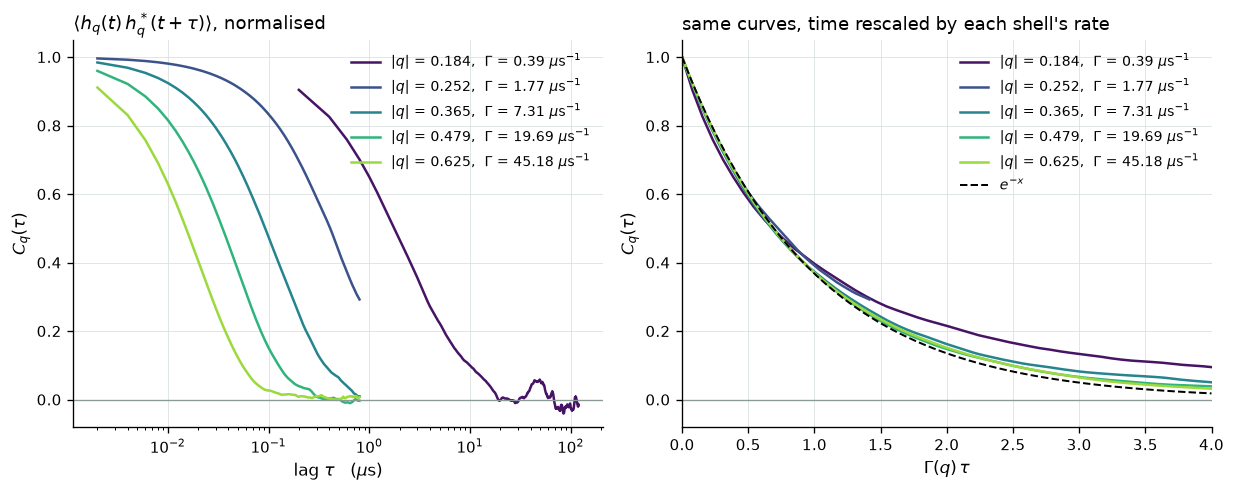

In [13]:
def shell_acf(acf, lo, hi):
    """Average the autocorrelation over the modes in one |q| shell."""
    m = (q > lo) & (q <= hi)
    return (acf[:, m].mean(axis=1), q[m].mean()) if m.any() else (None, None)


# shells chosen inside the resolved band of each run
shells = [(0.155, 0.20, acf_slow, dt_slow, g_slow),
          (0.24,  0.27, acf_fast, dt_fast, g_fast),
          (0.34,  0.39, acf_fast, dt_fast, g_fast),
          (0.45,  0.50, acf_fast, dt_fast, g_fast),
          (0.60,  0.65, acf_fast, dt_fast, g_fast)]
cmap = plt.cm.viridis(np.linspace(0.05, 0.85, len(shells)))

fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.2))
for (lo, hi, acf, dtf, grid), colour in zip(shells, cmap):
    c, qm = shell_acf(acf, lo, hi)
    if c is None:
        continue
    rate = np.nanmean(grid[(q > lo) & (q <= hi)])
    tau = np.arange(len(c)) * dtf
    lab = rf"$|q|$ = {qm:.3f},  $\Gamma$ = {rate:.2f} $\mu$s$^{{-1}}$"
    axes[0].plot(tau[1:], c[1:], color=colour, lw=1.5, label=lab)
    axes[1].plot(tau * rate, c, color=colour, lw=1.5, label=lab)

x = np.linspace(0, 4, 60)
axes[1].plot(x, np.exp(-x), "k--", lw=1.2, label=r"$e^{-x}$")
axes[1].set_xlim(0, 4)
axes[0].set_xscale("log")
axes[0].set_xlabel(r"lag $\tau$   ($\mu$s)")
axes[1].set_xlabel(r"$\Gamma(q)\,\tau$")
for ax, title in zip(axes, (r"$\langle h_q(t)\,h_q^*(t+\tau)\rangle$, normalised",
                            "same curves, time rescaled by each shell's rate")):
    ax.axhline(0, color=GREY, lw=0.8)
    ax.set_ylabel(r"$C_q(\tau)$")
    ax.set_ylim(-0.08, 1.05)
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

Single exponentials that collapse onto $e^{-x}$ once time is scaled by the
fitted rate — which is what an overdamped mode should do, and a useful check
that nothing in the sampling is distorting the correlation. The rates themselves
are the interesting part.

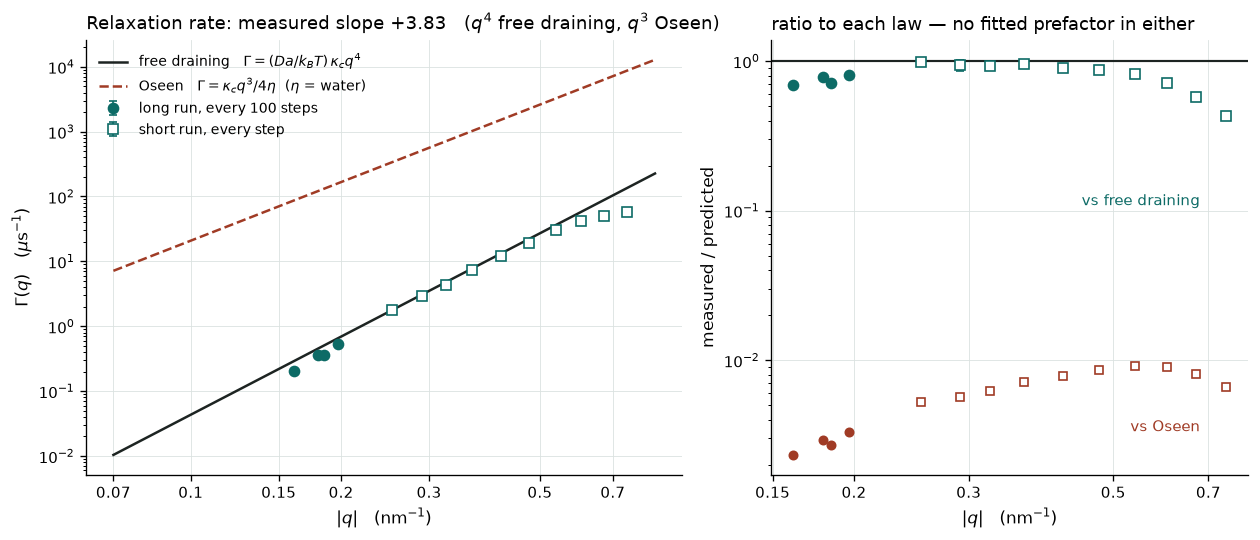

combined |q| range        : 0.161 .. 0.746 nm^-1
slope of Gamma(q)         : +3.83     (4 = free draining, 3 = Oseen)
median Gamma / free drain : 0.81
median Gamma / Oseen      : 6.39e-03


In [14]:
LAMBDA = DIFF * A_CELL / KBT          # nm^3/(pN us) -- the code's own mobility
ETA = 1.0e-3                          # pN.us/nm^2   (= 1 mPa.s, water)

fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.6),
                         gridspec_kw=dict(width_ratios=[1.25, 1]))
qline = np.logspace(np.log10(0.07), np.log10(0.85), 60)
axes[0].plot(qline, LAMBDA * KC_IN * qline ** 4, "-", color=INK, lw=1.5,
             label=r"free draining   $\Gamma = (Da/k_BT)\,\kappa_c q^4$")
axes[0].plot(qline, KC_IN * qline ** 3 / (4 * ETA), "--", color=BRICK, lw=1.5,
             label=r"Oseen   $\Gamma = \kappa_c q^3/4\eta$  ($\eta$ = water)")

allq, allg = [], []
for label, g, marker, fill in (("long run, every 100 steps", g_slow, "o", TEAL),
                               ("short run, every step", g_fast, "s", "white")):
    ok = np.isfinite(g)
    if not ok.any():
        continue
    qb, gb, ge, _ = ms.radial_average(q[ok], g[ok], n_bins=10)
    axes[0].errorbar(qb, gb, yerr=ge, fmt=marker, ms=6, color=TEAL, mfc=fill,
                     elinewidth=1, capsize=2.5, label=label, zorder=3)
    pb = LAMBDA * KC_IN * qb ** 4
    axes[1].errorbar(qb, gb / pb, yerr=ge / pb, fmt=marker, ms=6, color=TEAL,
                     mfc=fill, elinewidth=1, capsize=2.5, label=label)
    axes[1].errorbar(qb, gb / (KC_IN * qb ** 3 / (4 * ETA)), fmt=marker, ms=5,
                     color=BRICK, mfc=(BRICK if fill != "white" else "white"),
                     elinewidth=1, capsize=2)
    allq.append(qb); allg.append(gb)

allq = np.concatenate(allq); allg = np.concatenate(allg)
o = np.argsort(allq)
allq, allg = allq[o], allg[o]
pred = LAMBDA * KC_IN * allq ** 4
oseen = KC_IN * allq ** 3 / (4 * ETA)

axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel(r"$|q|$   (nm$^{-1}$)")
axes[0].set_ylabel(r"$\Gamma(q)$   ($\mu$s$^{-1}$)")
axes[0].set_title(rf"Relaxation rate: measured slope {ms.log_slope(allq, allg):+.2f}"
                  "   ($q^4$ free draining, $q^3$ Oseen)")
axes[0].legend(loc="upper left")

axes[1].axhline(1.0, color=INK, lw=1.3)
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel(r"$|q|$   (nm$^{-1}$)")
axes[1].set_ylabel("measured / predicted")
axes[1].set_title("ratio to each law — no fitted prefactor in either")
nice_logx(*axes)
axes[1].text(0.9, 0.62, "vs free draining", transform=axes[1].transAxes,
             ha="right", color=TEAL, fontsize=9)
axes[1].text(0.9, 0.10, "vs Oseen", transform=axes[1].transAxes,
             ha="right", color=BRICK, fontsize=9)
plt.tight_layout()
plt.show()

print(f"combined |q| range        : {allq.min():.3f} .. {allq.max():.3f} nm^-1")
print(f"slope of Gamma(q)         : {ms.log_slope(allq, allg):+.2f}"
      "     (4 = free draining, 3 = Oseen)")
print(f"median Gamma / free drain : {np.median(allg/pred):.2f}")
print(f"median Gamma / Oseen      : {np.median(allg/oseen):.2e}")

The measured rates sit on the free-draining line drawn from the run's *own*
`diffConst`, area per vertex and `kcMembraneBending` — there is no fitted
prefactor in it — and two orders of magnitude below the Oseen line.

That is not a near miss to be tuned away. `DynamicModel::next_step()` displaces
each vertex by $(D\,\mathrm{d}t/k_BT)F_i + \sqrt{2D\,\mathrm{d}t}\,\xi_i$: a scalar
mobility, per vertex, independent of every other vertex. There is no Oseen
tensor, no Rotne–Prager–Yamakawa, no mobility matrix anywhere in the repository,
so $\Gamma\propto q^4$ is what the integrator *is*, and a $q^{-3}$ decorrelation
cannot come out of it however the trajectory is analysed.

Two things worth knowing before reading any absolute timescale out of this model:

* **`diffConst` is not tied to a solvent.** It is a free per-vertex parameter in
  nm$^2/\mu$s, so absolute relaxation times are arbitrary until it is calibrated.
* **The free-draining rate is mesh dependent.**
  $\Gamma = (D a/k_BT)\kappa_c q^4$ is proportional to the area per vertex, so
  refining the mesh at fixed $D$ slows the dynamics by the refinement factor
  squared. The quantity to hold fixed for mesh-convergent dynamics is the
  mobility *per unit area*, $\Lambda = D a / k_BT$.

For a flat periodic sheet the Oseen mobility is diagonal in Fourier space, so
adding it would not need a dense mobility matrix at all: FFT the nodal force,
multiply by $\Lambda(q)\mathrm{d}t$, add noise of variance
$2k_BT\Lambda(q)\mathrm{d}t/A$ per mode — trivially square-rooted because the
mobility is diagonal, which is the expensive step in real space — and inverse
FFT. `analysis/reference_langevin.py` does exactly that and reproduces both
limbs: identical static spectra, $\Gamma$ slope 3.84 with the local mobility and
2.93 with Oseen.